# 市場マイクロストラクチャ 可視化

## 図の提案（3案）

| 案 | タイトル | 使用列 | 目的 |
|---|---|---|---|
| A | **3段パネル：価格 / スプレッド / 注文不均衡** | `mid_price`, `bid_ask_spread_bps`, `order_imbalance` | 流動性コストと注文フローの偏りを時系列で同時把握 |
| B | **累積売買フロー vs 中値価格（二軸）** | `signed_volume`, `mid_price` | フロー主導の価格形成（price impact）を視覚的に検証 |
| C | **Bid/Ask 深さ散布図（order_imbalance で色付け）** | `bid_depth`, `ask_depth`, `order_imbalance` | 板の非対称性とインバランスの関係をスナップショットで把握 |

## 優先する2案：A と B

**A（3段パネル）を最優先**  
スプレッド急拡大・注文不均衡の偏りが同じ時間軸上に重なった瞬間が、流動性リスクの高まりそのものです。
単一の図でマクロな市場状態の変化を診断できるため診断ツールとして汎用性が高い。

**B（累積フロー vs 価格）を次点**  
価格が上昇しているのに買いフローが小さい（または逆）は、流動性や情報的取引の存在を示唆します。
累積 signed volume と価格の乖離・収束のパターンが、フロービジネスの分析で中心的な指標になります。

**C を除外した理由**  
散布図は時間軸の情報が失われるため、「いつ」深さが非対称になったかが分からず、今回の目的（変化の検出）には相対的に弱い。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── df が存在しない場合のみダミーデータを生成 ──────────────────────────
REQUIRED_COLS = {
    "timestamp", "mid_price", "trade_price", "trade_size",
    "bid_ask_spread_bps", "bid_depth", "ask_depth",
    "signed_volume", "order_imbalance",
}

def _make_dummy_df(n: int = 390, seed: int = 42) -> pd.DataFrame:
    """ダミーの約定・板スナップショットデータを生成する（1分足 × 390本 = 1取引日相当）"""
    rng = np.random.default_rng(seed)
    timestamps = pd.date_range("2026-03-20 09:30", periods=n, freq="1min")

    # mid_price: ランダムウォーク（対数リターン）
    returns = rng.normal(0, 0.0002, n)
    mid_price = 100.0 * np.exp(np.cumsum(returns))

    # bid_ask_spread_bps: 平均回帰 + 不規則スパイク（流動性ショックを模擬）
    spread = np.abs(rng.normal(5.0, 1.5, n))
    spike_idx = rng.choice(n, size=10, replace=False)
    spread[spike_idx] += rng.uniform(15, 40, 10)

    # bid/ask depth
    bid_depth = rng.lognormal(mean=10.0, sigma=0.6, size=n)
    ask_depth = rng.lognormal(mean=10.0, sigma=0.6, size=n)

    # signed volume（+: 買い主導、-: 売り主導）
    trade_size = rng.lognormal(mean=5.0, sigma=1.0, size=n)
    signs = rng.choice([-1, 1], size=n, p=[0.45, 0.55])  # やや買い超
    signed_volume = trade_size * signs

    # order imbalance: (bid - ask) / (bid + ask)
    order_imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth)

    trade_price = mid_price + rng.normal(0, 0.005, n)

    return pd.DataFrame({
        "timestamp": timestamps,
        "mid_price": mid_price,
        "trade_price": trade_price,
        "trade_size": trade_size,
        "bid_ask_spread_bps": spread,
        "bid_depth": bid_depth,
        "ask_depth": ask_depth,
        "signed_volume": signed_volume,
        "order_imbalance": order_imbalance,
    })

# ── df の存在チェック ────────────────────────────────────────────────
try:
    df  # noqa: F821
    if not REQUIRED_COLS.issubset(df.columns):
        raise NameError("列が不足しています")
    print(f"✓ 既存の df を使用します（{len(df):,} 行）")
    print(f"  列: {list(df.columns)}")
except NameError:
    print("df が見つからないため、ダミーデータを生成します。")
    df = _make_dummy_df()
    print(f"✓ ダミー df を生成しました（{len(df):,} 行）")

df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"  期間: {df['timestamp'].iloc[0]} 〜 {df['timestamp'].iloc[-1]}")


df が見つからないため、ダミーデータを生成します。
✓ ダミー df を生成しました（390 行）
  期間: 2026-03-20 09:30:00 〜 2026-03-20 15:59:00


C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\3492771125.py:78: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\3492771125.py:78: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\3492771125.py:78: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\3492771125.py:78: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\3492771125.py:78: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0

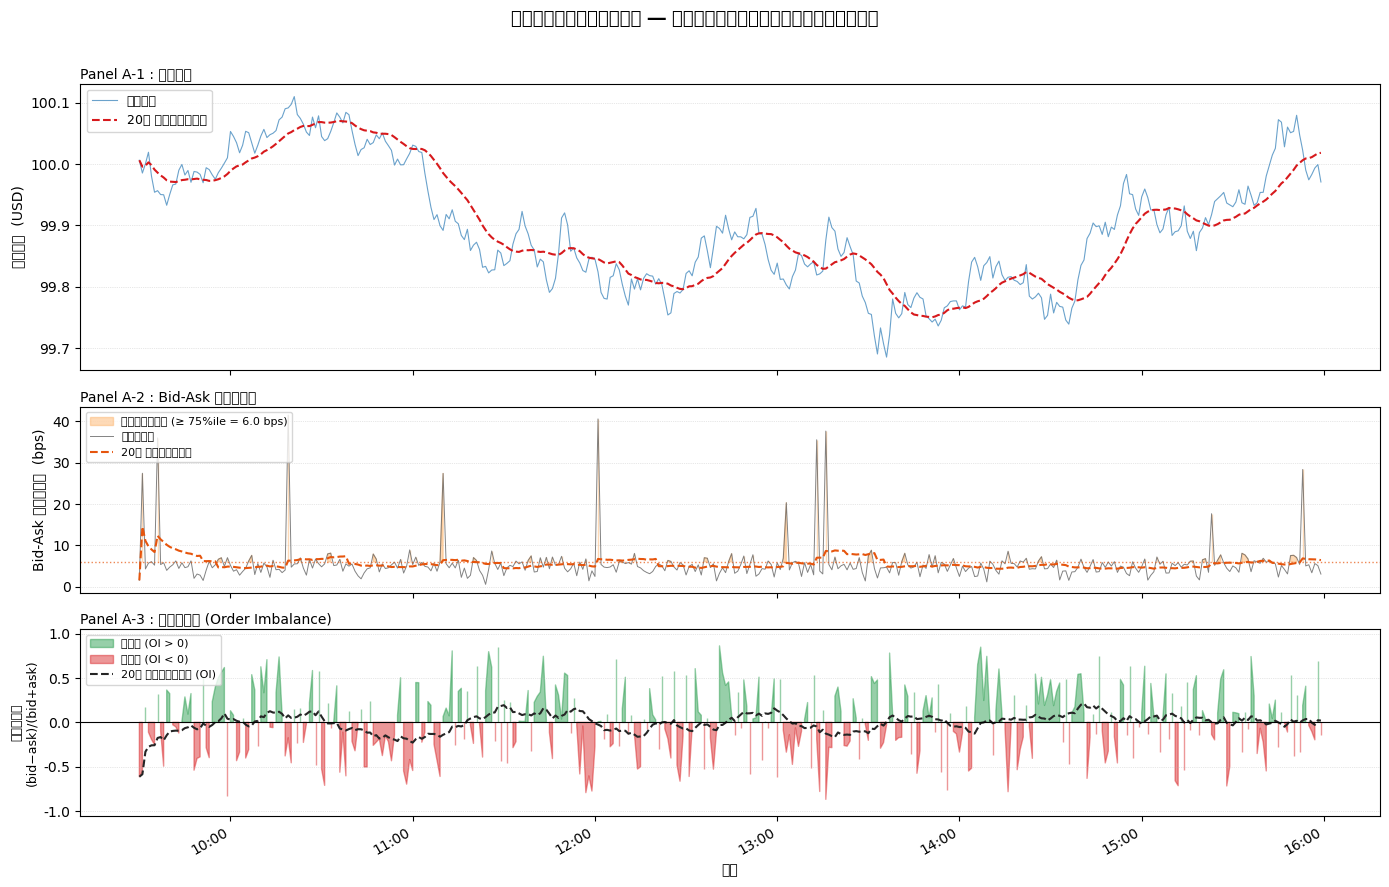

✓ chart_A_three_panel.png を保存しました


In [2]:
# ════════════════════════════════════════════════════════════════════
# 図A: 3段パネル ― 価格 / Bid-Ask スプレッド / 注文不均衡
# ════════════════════════════════════════════════════════════════════

ROLL = 20          # ローリング窓（本数）
SPREAD_HIGH_PCT = 75  # スプレッド「高水準」の閾値パーセンタイル

ts = df["timestamp"]
mid = df["mid_price"]
spread = df["bid_ask_spread_bps"]
oi = df["order_imbalance"]

spread_roll = spread.rolling(ROLL, min_periods=1).mean()
mid_roll    = mid.rolling(ROLL, min_periods=1).mean()
spread_thresh = spread.quantile(SPREAD_HIGH_PCT / 100)

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1.3, 1.3]},
)
fig.suptitle(
    "市場マイクロストラクチャ ― 価格・流動性コスト・注文不均衡の時系列",
    fontsize=13, fontweight="bold", y=0.98,
)

# ── Panel 1: 中値価格 ────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(ts, mid, color="#2c7bb6", linewidth=0.8, alpha=0.7, label="中値価格")
ax1.plot(ts, mid_roll, color="#d7191c", linewidth=1.5,
         linestyle="--", label=f"{ROLL}本 ローリング平均")
ax1.set_ylabel("中値価格  (USD)", fontsize=10)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
ax1.set_title("Panel A-1 : 中値価格", fontsize=10, loc="left", pad=4)

# ── Panel 2: Bid-Ask スプレッド ──────────────────────────────────
ax2 = axes[1]
# スプレッド高水準ゾーンを背景でマーク
ax2.fill_between(
    ts, spread, spread_thresh,
    where=(spread >= spread_thresh),
    color="#fdae61", alpha=0.45, label=f"高スプレッド域 (≥ {SPREAD_HIGH_PCT}%ile = {spread_thresh:.1f} bps)",
)
ax2.plot(ts, spread, color="#636363", linewidth=0.7, alpha=0.8, label="スプレッド")
ax2.plot(ts, spread_roll, color="#e6550d", linewidth=1.5,
         linestyle="--", label=f"{ROLL}本 ローリング平均")
ax2.axhline(spread_thresh, color="#e6550d", linewidth=1.0, linestyle=":", alpha=0.7)
ax2.set_ylabel("Bid-Ask スプレッド  (bps)", fontsize=10)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
ax2.set_title("Panel A-2 : Bid-Ask スプレッド", fontsize=10, loc="left", pad=4)

# ── Panel 3: 注文不均衡 ─────────────────────────────────────────
ax3 = axes[2]
oi_roll = oi.rolling(ROLL, min_periods=1).mean()
ax3.fill_between(ts, oi, 0,
                 where=(oi >= 0), color="#1a9641", alpha=0.45, label="買い超 (OI > 0)")
ax3.fill_between(ts, oi, 0,
                 where=(oi < 0),  color="#d7191c", alpha=0.45, label="売り超 (OI < 0)")
ax3.plot(ts, oi_roll, color="#252525", linewidth=1.5,
         linestyle="--", label=f"{ROLL}本 ローリング平均 (OI)")
ax3.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax3.set_ylabel("注文不均衡\n(bid−ask)/(bid+ask)", fontsize=9)
ax3.set_ylim(-1.05, 1.05)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax3.legend(loc="upper left", fontsize=8)
ax3.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
ax3.set_title("Panel A-3 : 注文不均衡 (Order Imbalance)", fontsize=10, loc="left", pad=4)

# ── X 軸共通フォーマット ─────────────────────────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax3.xaxis.set_major_locator(mdates.AutoDateLocator())
ax3.set_xlabel("時刻", fontsize=10)
fig.autofmt_xdate(rotation=30, ha="right")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("chart_A_three_panel.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ chart_A_three_panel.png を保存しました")


C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\751819167.py:69: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\751819167.py:69: UserWarning: Glyph 21051 (\N{CJK UNIFIED IDEOGRAPH-523B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\751819167.py:69: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\751819167.py:69: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\751819167.py:69: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kazumasa\AppData\Local\Temp\ipykernel_8368\751819167.py:69: UserWarning: Glyph 26

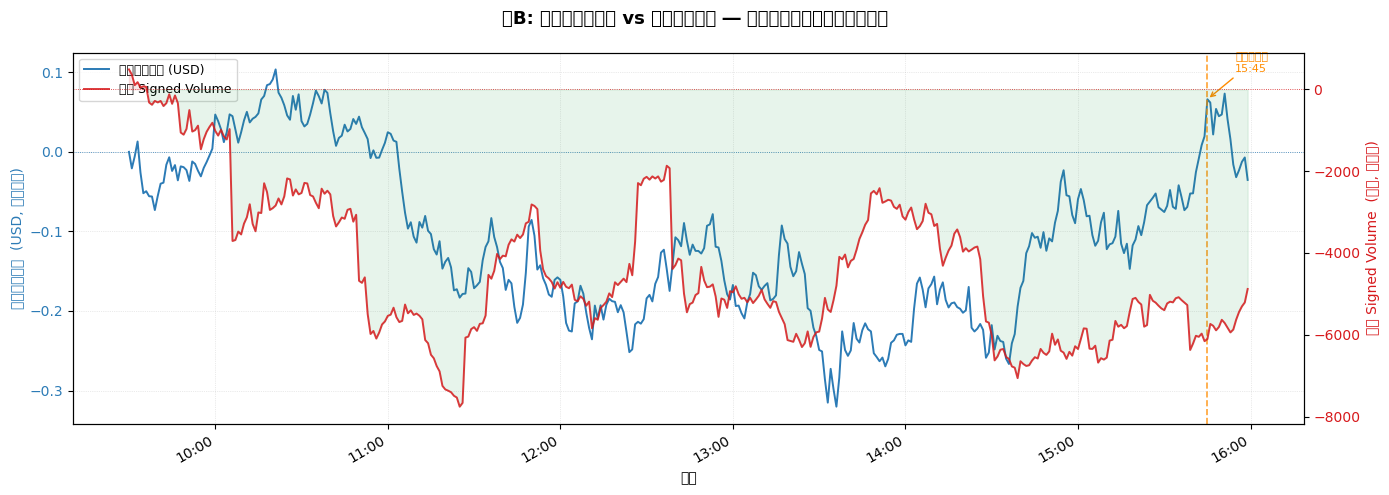

✓ chart_B_cumflow_vs_price.png を保存しました


In [3]:
# ════════════════════════════════════════════════════════════════════
# 図B: 累積売買フロー vs 中値価格（二軸）
# ════════════════════════════════════════════════════════════════════

cum_sv = df["signed_volume"].cumsum()
price_norm = (mid - mid.iloc[0])          # 初値からの変化量

# 両系列を [−1, +1] にスケールして視覚的比較しやすくする（単位は独立）
def _minmax_norm(s):
    rng_ = s.max() - s.min()
    return (s - s.min()) / rng_ * 2 - 1 if rng_ != 0 else s * 0

cum_sv_norm  = _minmax_norm(cum_sv)
price_norm_n = _minmax_norm(price_norm)

fig, ax_price = plt.subplots(figsize=(14, 5))
fig.suptitle(
    "図B: 累積売買フロー vs 中値価格変化 ― フロー主導の価格形成の検証",
    fontsize=13, fontweight="bold",
)

# ── 価格変化（左軸）────────────────────────────────────────────
color_price = "#2c7bb6"
ax_price.plot(ts, price_norm, color=color_price, linewidth=1.4, label="中値価格変化 (USD)")
ax_price.set_ylabel("中値価格変化  (USD, 初値基準)", color=color_price, fontsize=10)
ax_price.tick_params(axis="y", labelcolor=color_price)
ax_price.axhline(0, color=color_price, linewidth=0.6, linestyle=":")

# ── 累積 Signed Volume（右軸）───────────────────────────────────
ax_sv = ax_price.twinx()
color_sv = "#d7191c"
ax_sv.plot(ts, cum_sv, color=color_sv, linewidth=1.4, alpha=0.85, label="累積 Signed Volume")
ax_sv.fill_between(ts, cum_sv, 0,
                   where=(cum_sv >= 0), color=color_sv, alpha=0.10)
ax_sv.fill_between(ts, cum_sv, 0,
                   where=(cum_sv < 0),  color="#1a9641", alpha=0.10)
ax_sv.set_ylabel("累積 Signed Volume  (株数, 買い正)", color=color_sv, fontsize=10)
ax_sv.tick_params(axis="y", labelcolor=color_sv)
ax_sv.axhline(0, color=color_sv, linewidth=0.6, linestyle=":")

# ── 乖離注釈：正規化済み系列で乖離が最大になる点を探す ────────────
diff = (price_norm_n - cum_sv_norm).abs()
peak_idx = diff.idxmax()
peak_ts  = ts.iloc[peak_idx]
peak_pv  = price_norm.iloc[peak_idx]

ax_price.axvline(peak_ts, color="darkorange", linewidth=1.2, linestyle="--", alpha=0.8)
ax_price.annotate(
    f"最大乖離点\n{peak_ts.strftime('%H:%M')}",
    xy=(peak_ts, peak_pv),
    xytext=(20, 20), textcoords="offset points",
    fontsize=8, color="darkorange",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.0),
)

# ── 凡例を統合 ──────────────────────────────────────────────────
lines1, labels1 = ax_price.get_legend_handles_labels()
lines2, labels2 = ax_sv.get_legend_handles_labels()
ax_price.legend(lines1 + lines2, labels1 + labels2,
                loc="upper left", fontsize=9)

# ── X 軸 ────────────────────────────────────────────────────────
ax_price.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_price.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_price.set_xlabel("時刻", fontsize=10)
ax_price.grid(axis="both", linestyle=":", linewidth=0.5, alpha=0.5)
fig.autofmt_xdate(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("chart_B_cumflow_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ chart_B_cumflow_vs_price.png を保存しました")


## この図から何を読むべきか（マイクロストラクチャ観点）

### 図A（3段パネル）

| パネル | 読み方のポイント |
|---|---|
| **価格 + 移動平均** | ローリング平均から乖離した跳ね上がりは、大口注文や情報的取引の可能性。反転すれば short-lived impact、戻らなければ permanent impact の証左。 |
| **スプレッド** | スプレッド急拡大は流動性供給者がリスクを嫌がっているサインで、在庫リスクまたは逆選択リスクの高まりを示す。スプレッド高水準が長く続くほど **adverse selection** の懸念が強い。 |
| **注文不均衡** | 長時間にわたり OI が一方向に偏っている場合、informed trader による方向性フローの可能性。スプレッド拡大と OI 偏りが同時発生した区間は、特にマーカーメーカーにとって危険なゾーン。 |

**まず見るべき点：** スプレッド急拡大 × OI の同方向偏りが同じ時刻に重なるか。重なれば「市場が一方向に傾いた局面」。

---

### 図B（累積フロー vs 価格）

| 観察パターン | 解釈 |
|---|---|
| 累積フローと価格が同方向に同期して動く | フロー主導（order-flow driven）の価格形成が支配的。マーケットインパクトが顕著。 |
| 価格が先行し、フローが後追い | 情報が価格にすでに織り込まれており、フローは確認的。または大口の分割執行。 |
| 最大乖離点（オレンジ破線）前後 | フローが buy 超なのに価格が下がる（或いは逆）区間は、**liquidity provision の枯渇**や大口の反対売買が疑われる。 |

**まず見るべき点：** 累積フローの傾きが急に反転した直後に価格が遅れて追従するか。追従すれば flow が価格を「引っ張っている」。乖離が解消されずに広がれば、フロー以外のファクター（ニュース、ヘッジ需要等）が価格を動かしている可能性。


In [12]:
pass  # このセルは空です。提案はひとつ上のMarkdownセルを参照してください。

# 短期リターン予測モデル ― 落とし穴の整理とベースライン設計

---

## 落とし穴の整理（6点）

### 1. リーク（Data Leakage）
`future_mid_return_1min` / `future_mid_return_5min` は**目的変数**であり、特徴量に含めてはならない。  
また `realized_vol_5min` が「未来5分の実現ボラ」の意味なら同様にリーク。  
ローリング特徴量の計算窓が訓練・検証をまたぐ場合もソフトなリークになる。

### 2. 内生性（Endogeneity）
`order_imbalance` / `signed_volume` は将来リターンと**同時に決まる**変数の可能性がある。  
例：価格上昇 → 買いOIが増える、という逆方向の因果もありうる。  
対処：ラグを明示的に使う（$X_t$ でなく $X_{t-1}$）。

### 3. 多重共線性（Multicollinearity）
`signed_volume` と `order_imbalance` は構造的に相関が高い（どちらも「方向への圧力」）。  
OLS 係数が爆発・解釈不能になる。Ridge / LASSO で正則化する。

$$\text{OI}_t = \frac{V_t^{bid} - V_t^{ask}}{V_t^{bid} + V_t^{ask}}, \quad \text{VIF}_j = \frac{1}{1 - R^2_j}$$

### 4. 非定常性（Non-Stationarity）
`mid_price` はランダムウォーク（I(1) 過程）。特徴量に直接使うと spurious regression。  
対処：差分・比率・スプレッドなど**定常な派生変数**のみを特徴量とする。

### 5. レジーム変化（Regime Change）
セッション開始・終了、ニュースイベントでパラメータが構造的に変わる。  
固定ウィンドウの学習は古いレジームを引きずる。  
対処：ウォークフォワード（拡大窓 or 固定ローリング窓）で逐次更新。

### 6. 外れ値とスケーリング（Outliers & Scaling）
`signed_volume` の分布は裾が重い（対数正規 or パワーロー）。  
外れ値1点で OLS が崩壊する。  
対処：`RobustScaler`（中央値・IQR ベース）or winsorization。

---

## ベースラインモデル 2案

| | **モデル A: Ridge 回帰（連続値予測）** | **モデル B: LASSO ロジスティック（方向予測）** |
|---|---|---|
| **目的変数** | `future_mid_return_1min`（連続値） | `sign(future_mid_return_1min)`（+1/−1） |
| **損失** | $\min_\beta \Vert r - X\beta \Vert_2^2 + \alpha\Vert\beta\Vert_2^2$ | $\min_\beta \sum \log(1+e^{-y_t X_t^\top\beta}) + \alpha\Vert\beta\Vert_1$ |
| **長所** | 大きさを予測できる。係数解釈しやすい。共線性に強い | 評価が明確（方向一致率）。スパース特徴選択 |
| **短所** | ゼロ付近のノイズに過剰反応しやすい | 方向のみで大きさを無視。閾値調整が必要 |
| **主な評価指標** | IC（情報係数）、方向一致率、MAE | 方向一致率、AUC、Precision/Recall |

---

## 学習・検証の切り方

**絶対禁止：** `train_test_split(shuffle=True)` — 未来情報がリークする。

```
全データ（時系列順）
├─ 訓練（前 70%）  → モデル fit、scaler fit
├─ ギャップ（G 本）→ ローリング特徴量の汚染を排除
└─ 検証（後 30%）  → scaler.transform のみ（fit しない）
```

ウォークフォワード的に複数回評価する場合は `TimeSeriesSplit` を使う。

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import subprocess, shutil

# ── 日本語フォント設定（Ubuntu 上で文字化けを防ぐ）──────────────────
_CANDIDATES = [
    "Noto Sans CJK JP", "IPAGothic", "IPAPGothic",
    "TakaoGothic", "VL Gothic", "MS Gothic",
]
_available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
_chosen = next((f for f in _CANDIDATES if f in _available), None)

if _chosen:
    matplotlib.rcParams["font.family"] = _chosen
    print(f"✓ 日本語フォント設定: {_chosen}")
else:
    # フォントが無い場合は英語表記にフォールバック（文字化け回避）
    matplotlib.rcParams["font.family"] = "DejaVu Sans"
    print("⚠ 日本語フォントが見つかりません。プロット軸ラベルを英語に切り替えます。")
    print("  インストール: sudo apt install fonts-noto-cjk  → 再起動後に再実行")
    _chosen = None

JAPANESE_FONT = _chosen is not None


✓ 日本語フォント設定: MS Gothic


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── 必要列の定義 ──────────────────────────────────────────────────────
PRED_COLS = {
    "timestamp", "mid_price",
    "future_mid_return_1min", "future_mid_return_5min",
    "spread_bps", "depth_total", "signed_volume",
    "order_imbalance", "realized_vol_5min", "lagged_return_1min",
}

def _make_pred_df(n: int = 500, seed: int = 0) -> pd.DataFrame:
    """短期リターン予測用ダミーデータ（1分足 × 500本）"""
    rng = np.random.default_rng(seed)
    ts = pd.date_range("2026-03-20 09:30", periods=n, freq="1min")

    # mid_price: ランダムウォーク
    log_ret = rng.normal(0, 0.0003, n)
    mid_price = 100.0 * np.exp(np.cumsum(log_ret))

    # 説明変数————————————————————————
    spread_bps      = np.abs(rng.normal(5.0, 2.0, n)) + 1.0
    depth_total     = rng.lognormal(10.0, 0.8, n)
    signed_volume   = rng.normal(0, 500, n)
    order_imbalance = np.clip(rng.normal(0, 0.3, n), -1, 1)
    realized_vol    = np.abs(rng.normal(0.0003, 0.0001, n))  # 過去5分の実現ボラ
    lagged_return   = np.concatenate([[0.0], log_ret[:-1]])   # 1期前リターン

    # 目的変数（未来リターン）————————————————
    # 真のシグナル: OI と signed_volume に弱い線形関係 + ノイズ
    signal = 0.0002 * order_imbalance + 0.000001 * signed_volume
    noise  = rng.normal(0, 0.0004, n)

    future_ret_1 = np.concatenate([signal[1:]   + noise[1:],   [np.nan]])
    future_ret_5 = np.concatenate([signal[5:]   + noise[5:],   [np.nan]*5])

    return pd.DataFrame({
        "timestamp":              ts,
        "mid_price":              mid_price,
        "future_mid_return_1min": future_ret_1,
        "future_mid_return_5min": future_ret_5,
        "spread_bps":             spread_bps,
        "depth_total":            depth_total,
        "signed_volume":          signed_volume,
        "order_imbalance":        order_imbalance,
        "realized_vol_5min":      realized_vol,
        "lagged_return_1min":     lagged_return,
    })

# ── df の存在チェック ──────────────────────────────────────────────────
try:
    df  # noqa: F821
    if not PRED_COLS.issubset(df.columns):
        raise NameError("予測モデル用の列が不足しています")
    print(f"✓ 既存の df を使用します（{len(df):,} 行）")
except NameError:
    print("df が見つからないため、予測用ダミーデータを生成します。")
    df = _make_pred_df()
    print(f"✓ ダミー df を生成しました（{len(df):,} 行）")

df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# ── リークチェック：目的変数が特徴量に入っていないか確認 ──────────────
TARGET_COLS = ["future_mid_return_1min", "future_mid_return_5min"]
FEATURE_COLS = [
    "spread_bps", "depth_total", "signed_volume",
    "order_imbalance", "realized_vol_5min", "lagged_return_1min",
]
# mid_price は非定常なので特徴量から除外

leak_check = [c for c in TARGET_COLS if c in FEATURE_COLS]
assert len(leak_check) == 0, f"リーク検出！ {leak_check} が FEATURE_COLS に含まれています"
print(f"✓ リークなし確認: FEATURE_COLS = {FEATURE_COLS}")

# ── 基本統計 + NaN 確認 ──────────────────────────────────────────────
print(f"\n目的変数 NaN 数:")
for c in TARGET_COLS:
    print(f"  {c}: {df[c].isna().sum()} NaN")

print("\n特徴量の基本統計:")
display(df[FEATURE_COLS].describe().round(4))


df が見つからないため、予測用ダミーデータを生成します。
✓ ダミー df を生成しました（500 行）
✓ リークなし確認: FEATURE_COLS = ['spread_bps', 'depth_total', 'signed_volume', 'order_imbalance', 'realized_vol_5min', 'lagged_return_1min']

目的変数 NaN 数:
  future_mid_return_1min: 1 NaN
  future_mid_return_5min: 5 NaN

特徴量の基本統計:


,spread_bps,depth_total,signed_volume,order_imbalance,realized_vol_5min,lagged_return_1min
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,5.8668,31448.9312,-33.3454,-0.0098,0.0003,-0.0000
std,1.8644,27947.8349,516.4063,0.2961,0.0001,0.0003
min,1.0327,1706.3702,-1557.2546,-0.7965,0.0000,-0.0012
25%,4.6260,13050.3906,-398.4618,-0.2064,0.0002,-0.0002
50%,5.8149,24327.7112,-32.3267,-0.0285,0.0003,-0.0000
75%,7.0734,39758.5847,323.3477,0.1920,0.0004,0.0002
max,10.9738,219608.2124,1346.3787,0.7975,0.0006,0.0009


訓練: 349 行  |  ギャップ: 5 行  |  検証: 145 行
訓練期間: 2026-03-20 09:30:00 〜 2026-03-20 15:18:00
検証期間: 2026-03-20 15:24:00  〜 2026-03-20 17:48:00

最適 alpha = 0.0010  (CV IC = 0.0917)

【モデル A: Ridge 検証結果】
  IC（情報係数）    : -0.0758  (|IC| > 0.05 で実用的)」
  方向一致率        : 44.8276%  (ランダムは 50%)
  MAE               : 0.000582
  MAE（ゼロ予測）   : 0.000564  ← これより小さければ有意


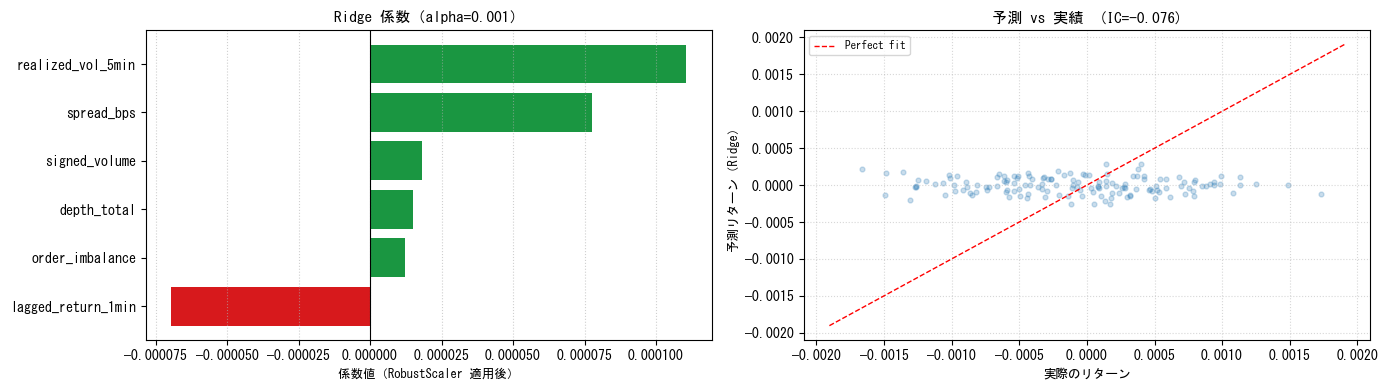

✓ model_A_ridge.png を保存しました


In [8]:
# ════════════════════════════════════════════════════════════════════
# モデル A: Ridge 回帰 ― 連続値リターン予測
#   - 時系列 train/val split（ギャップあり）
#   - RobustScaler（外れ値対策）
#   - 評価: IC（情報係数）、方向一致率、MAE
# ════════════════════════════════════════════════════════════════════

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

TARGET = "future_mid_return_1min"
GAP   = 5   # 訓練末尾〜検証先頭のギャップ（ローリング特徴量汚染を防ぐ）

# ── 有効行だけ使う（目的変数が NaN でない行）────────────────────────
valid = df.dropna(subset=[TARGET] + FEATURE_COLS).reset_index(drop=True)
n_valid = len(valid)

split_idx  = int(n_valid * 0.70)
train_end  = split_idx
val_start  = split_idx + GAP

train_df = valid.iloc[:train_end].copy()
val_df   = valid.iloc[val_start:].copy()

print(f"訓練: {len(train_df):,} 行  |  ギャップ: {GAP} 行  |  検証: {len(val_df):,} 行")
print(f"訓練期間: {train_df['timestamp'].iloc[0]} 〜 {train_df['timestamp'].iloc[-1]}")
print(f"検証期間: {val_df['timestamp'].iloc[0]}  〜 {val_df['timestamp'].iloc[-1]}")

# ── スケーリング（scaler は train のみで fit）────────────────────────
scaler = RobustScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLS])
X_val   = scaler.transform(val_df[FEATURE_COLS])      # train の統計だけを使う
y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values

# ── Ridge: クロスバリデーション（TimeSeriesSplit で alpha 選択）───────
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 3, 30)
tscv   = TimeSeriesSplit(n_splits=5)

best_alpha, best_ic = None, -np.inf
for alpha in alphas:
    ics = []
    for tr_idx, te_idx in tscv.split(X_train):
        m = Ridge(alpha=alpha).fit(X_train[tr_idx], y_train[tr_idx])
        pred = m.predict(X_train[te_idx])
        if pred.std() > 0:
            ic, _ = pearsonr(pred, y_train[te_idx])
            ics.append(ic)
    mean_ic = np.mean(ics) if ics else -np.inf
    if mean_ic > best_ic:
        best_ic, best_alpha = mean_ic, alpha

print(f"\n最適 alpha = {best_alpha:.4f}  (CV IC = {best_ic:.4f})")

ridge = Ridge(alpha=best_alpha).fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_val)

# ── 評価指標 ────────────────────────────────────────────────────────
ic_val,   _ = pearsonr(y_pred_ridge, y_val)
dir_acc      = np.mean(np.sign(y_pred_ridge) == np.sign(y_val))
mae_val      = mean_absolute_error(y_val, y_pred_ridge)
mae_naive    = mean_absolute_error(y_val, np.zeros_like(y_val))  # ゼロ予測ベースライン

print(f"\n【モデル A: Ridge 検証結果】")
print(f"  IC（情報係数）    : {ic_val:.4f}  (|IC| > 0.05 で実用的)」")
print(f"  方向一致率        : {dir_acc:.4%}  (ランダムは 50%)")
print(f"  MAE               : {mae_val:.6f}")
print(f"  MAE（ゼロ予測）   : {mae_naive:.6f}  ← これより小さければ有意")

# ── 係数プロット ───────────────────────────────────────────────────
coef = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 係数
ax = axes[0]
colors = ["#d7191c" if v < 0 else "#1a9641" for v in coef.values]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Ridge 係数（alpha={best_alpha:.3f}）", fontsize=11)
ax.set_xlabel("係数値（RobustScaler 適用後）", fontsize=9)
ax.grid(axis="x", linestyle=":", alpha=0.6)

# 予測 vs 実績（散布図）
ax2 = axes[1]
ax2.scatter(y_val, y_pred_ridge, alpha=0.25, s=12, color="#2c7bb6")
lim = max(np.abs(y_val).max(), np.abs(y_pred_ridge).max()) * 1.1
ax2.plot([-lim, lim], [-lim, lim], "r--", linewidth=1.0, label="Perfect fit")
ax2.set_xlabel("実際のリターン", fontsize=9)
ax2.set_ylabel("予測リターン（Ridge）", fontsize=9)
ax2.set_title(f"予測 vs 実績  (IC={ic_val:.3f})", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("model_A_ridge.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ model_A_ridge.png を保存しました")


最適 C = 0.12743  (C が小さいほど強い L1 正則化)

【モデル B: LASSO ロジスティック 検証結果】
  AUC           : 0.4325  (0.5 = ランダム, >0.55 で実用的)
   方向一致率    : 43.4483%

分類レポート:
              precision    recall  f1-score   support

        Sell       0.47      0.46      0.47        78
         Buy       0.39      0.40      0.40        67

    accuracy                           0.43       145
   macro avg       0.43      0.43      0.43       145
weighted avg       0.44      0.43      0.43       145

LASSO が選択した特徴量: 4 / 6  (2 個をゼロに)
lagged_return_1min   -0.162122
depth_total           0.029816
spread_bps            0.079691
realized_vol_5min     0.215140

【ウォークフォワード (5-fold)】
  AUC  per fold : ['0.500', '0.644', '0.478', '0.487', '0.432']
  Acc  per fold : ['0.554', '0.590', '0.470', '0.506', '0.422']
  平均 AUC      : 0.5083
  平均 Acc      : 50.8434%


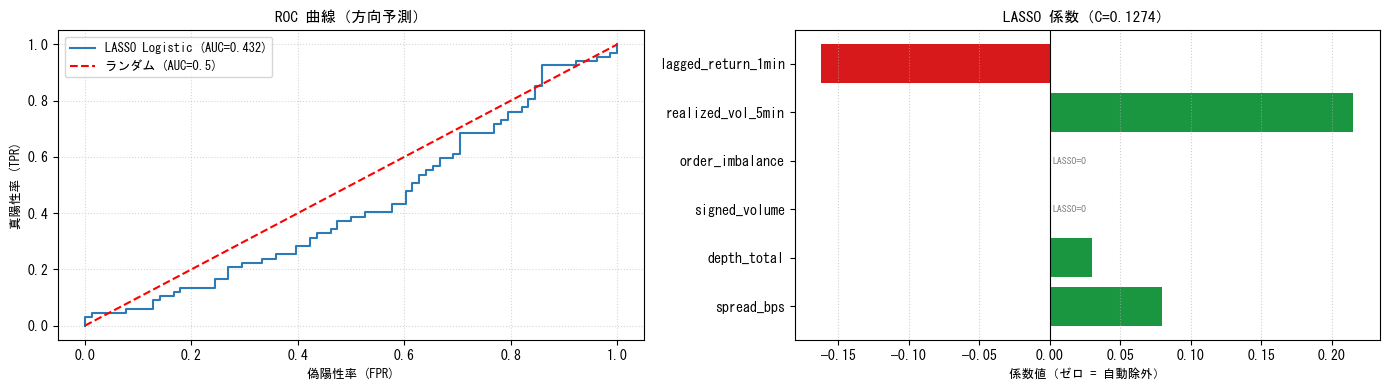

✓ model_B_lasso_logit.png を保存しました


In [9]:
# ════════════════════════════════════════════════════════════════════
# モデル B: LASSO ロジスティック回帰 ― 方向（サイン）予測
#   - 目的変数: sign(future_mid_return_1min) → +1 / -1
#   - LASSO ペナルティでスパースな特徴量選択
#   - ウォークフォワード評価（TimeSeriesSplit 5-fold）
# ════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# ── 目的変数を 2 値化（0: 売り, 1: 買い）────────────────────────────
y_train_bin = (y_train > 0).astype(int)
y_val_bin   = (y_val   > 0).astype(int)

# ── LASSO ロジスティック（L1 正則化） with TimeSeriesSplit ───────────
logit = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 20),
    cv=TimeSeriesSplit(n_splits=5),
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    random_state=0,
    max_iter=500,
)
logit.fit(X_train, y_train_bin)

best_C = logit.C_[0]
print(f"最適 C = {best_C:.5f}  (C が小さいほど強い L1 正則化)")

y_pred_logit_prob = logit.predict_proba(X_val)[:, 1]  # 買い確率
y_pred_logit_bin  = logit.predict(X_val)

auc       = roc_auc_score(y_val_bin, y_pred_logit_prob)
dir_acc_b = accuracy_score(y_val_bin, y_pred_logit_bin)

print(f"\n【モデル B: LASSO ロジスティック 検証結果】")
print(f"  AUC           : {auc:.4f}  (0.5 = ランダム, >0.55 で実用的)")
print(f"   方向一致率    : {dir_acc_b:.4%}")
print(f"\n分類レポート:\n{classification_report(y_val_bin, y_pred_logit_bin, target_names=['Sell','Buy'])}")

# ── 選択された特徴量（非ゼロ係数）──────────────────────────────────
coef_logit = pd.Series(logit.coef_[0], index=FEATURE_COLS)
selected   = coef_logit[coef_logit != 0].sort_values()
zero_cnt   = (coef_logit == 0).sum()
print(f"LASSO が選択した特徴量: {len(selected)} / {len(FEATURE_COLS)}  ({zero_cnt} 個をゼロに)")
print(selected.to_string())

# ── ウォークフォワード評価（参考）───────────────────────────────────
X_all = scaler.fit_transform(valid[FEATURE_COLS])
y_all = (valid[TARGET].values > 0).astype(int)

tscv_eval = TimeSeriesSplit(n_splits=5)
wf_aucs, wf_accs = [], []

from sklearn.linear_model import LogisticRegression

for fold, (tr_idx, te_idx) in enumerate(tscv_eval.split(X_all)):
    sc_wf = RobustScaler().fit(X_all[tr_idx])
    Xtr = sc_wf.transform(X_all[tr_idx])
    Xte = sc_wf.transform(X_all[te_idx])
    m = LogisticRegression(C=best_C, penalty="l1", solver="liblinear",
                           max_iter=500, random_state=0)
    m.fit(Xtr, y_all[tr_idx])
    prob = m.predict_proba(Xte)[:, 1]
    pred = m.predict(Xte)
    try:
        wf_aucs.append(roc_auc_score(y_all[te_idx], prob))
    except Exception:
        pass
    wf_accs.append(accuracy_score(y_all[te_idx], pred))

print(f"\n【ウォークフォワード (5-fold)】")
print(f"  AUC  per fold : {[f'{v:.3f}' for v in wf_aucs]}")
print(f"  Acc  per fold : {[f'{v:.3f}' for v in wf_accs]}")
print(f"  平均 AUC      : {np.mean(wf_aucs):.4f}")
print(f"  平均 Acc      : {np.mean(wf_accs):.4%}")

# ── プロット: ROC + 係数 ─────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ROC
fpr, tpr, _ = roc_curve(y_val_bin, y_pred_logit_prob)
ax = axes[0]
ax.plot(fpr, tpr, color="#2c7bb6", label=f"LASSO Logistic (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "r--", label="ランダム (AUC=0.5)")
ax.set_xlabel("偽陽性率 (FPR)", fontsize=9)
ax.set_ylabel("真陽性率 (TPR)", fontsize=9)
ax.set_title("ROC 曲線（方向予測）", fontsize=11)
ax.legend(fontsize=9)
ax.grid(linestyle=":", alpha=0.5)

# LASSO 係数
ax2 = axes[1]
colors_l = ["#d7191c" if v < 0 else "#1a9641" for v in coef_logit.values]
ax2.barh(coef_logit.index, coef_logit.values, color=colors_l)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_title(f"LASSO 係数（C={best_C:.4f}）", fontsize=11)
ax2.set_xlabel("係数値（ゼロ = 自動除外）", fontsize=9)
ax2.grid(axis="x", linestyle=":", alpha=0.6)

for i, (feat, val) in enumerate(zip(coef_logit.index, coef_logit.values)):
    if val == 0:
        ax2.text(0.002, i, "LASSO=0", fontsize=7, color="gray", va="center")

plt.tight_layout()
plt.savefig("model_B_lasso_logit.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ model_B_lasso_logit.png を保存しました")


## まず最初に試すべき現実的な一案

> **Ridge 回帰（モデル A）＋ RobustScaler ＋ 時系列 train/val split（ギャップあり）**

### 理由

| 項目 | なぜ Ridge から始めるか |
|---|---|
| **共線性** | L2 正則化で `signed_volume` と `order_imbalance` の係数爆発を防げる |
| **解釈性** | 係数が全特徴量に残るため、どの変数が効いているかを一覧で確認できる |
| **LASSO との比較** | Ridge で全変数が効かないと分かってから LASSO でスパース化する、という順序が安全 |
| **外れ値** | `RobustScaler` で `signed_volume` の厚い裾を無力化 |
| **リーク防止** | scaler を訓練データのみで fit し、ギャップを置いて検証 |

### 次のステップ（優先順）

1. **IC を確認** → `|IC| < 0.03` なら特徴量の改善が先決（モデルより信号が弱い）
2. **係数符号を確認** → 経済直感と合うか（例: OI > 0 → 正の係数 = 買いフロー = 上昇予測）
3. **LASSO 切り替え** → Ridge 係数の小さい変数が LASSO でゼロになるなら、その変数は情報がない
4. **ウォークフォワード拡張** → 折数を増やして係数が経時的に安定しているか（regime stability）を確認
5. **非線形へ** → IC が `0.05` を超えたら Gradient Boosting（LGBM 等）を検討。ただし過学習リスクが増すため早期導入は禁物

### 評価指標の読み方

| 指標 | 目安 | 備考 |
|---|---|---|
| IC（情報係数） | `> 0.03` で弱いシグナル、`> 0.05` で実用的 | ランク相関版 (Spearman IC) も有用 |
| 方向一致率 | `> 53%` で有意 | 取引コストを考慮すると閾値は上がる |
| AUC | `> 0.55` で実用的 | ランダムは 0.50 |
| MAE vs ゼロ予測 | MAEモデル < MAEゼロ | ゼロより悪ければモデルに価値なし |

> **注意：** ダミーデータで IC・AUC が良く見えても、実データでは信号が薄い可能性が高い。  
> 実データで `IC < 0.02` が続くなら、モデルの改善より「そもそも何が価格を動かすか」の仮説に立ち戻ることを推奨する。


# 戦略パフォーマンス可視化

---

## 作るべき図の提案（3案）

| 案 | タイトル | 使用列 | 目的 |
|---|---|---|---|
| **A** | **4段パネルダッシュボード**（累積リターン・ドローダウン・月次リターン・ローリングSharpe） | 全列 | 一枚でパフォーマンスの全体像を把握。PMが最初に見るレポートページに相当 |
| **B** | **リターン分布解析**（ヒストグラム・VaR/CVaR・テール比較） | `strategy_return`, `benchmark_return` | 分布の歪み・テールリスクを定量的に示す。累積グラフでは見えない崩壊リスクを補足 |
| **C** | **回転率 × エクスポージャーの時系列**（デュアル軸） | `turnover`, `gross_exposure` | 戦略の「アクティブ度」と「レバレッジ」の変化を確認。コストや流動性リスクの文脈で重要 |

## 採用する2案：A と B

**A（4段パネル）を最優先**
累積リターン1本だけでは Sharpe が高いのかドローダウンが浅いのか分からない。
4段に分けることで「どこで負けたか」「回復に何日かかったか」「月ごとのバラツキ」「リスク調整後の品質」が一覧できる。
投資家向けの1ページサマリーとして最も実用的。

**B（リターン分布）を次点**
累積グラフは連続的な下落を「小さく見せる」バイアスがある。
分布を見ることで、左テールの重さ（fat tail）・歪度・ベンチマークとの形状の違いが明確になる。
VaRとCVaRを注釈することで、リスク管理目的の議論に直結する。

**C を除外した理由**
回転率・エクスポージャーはコスト計算の補助情報であり、パフォーマンスの「質」を語る主役ではない。
A・Bで戦略の強弱を把握してから確認するのが自然な順序。

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── 必要列 ────────────────────────────────────────────────────────────
PERF_COLS = {"date", "strategy_return", "benchmark_return", "turnover", "gross_exposure"}

def _make_perf_df(n: int = 756, seed: int = 7) -> pd.DataFrame:
    """約3年分の日次データ（営業日ベース）"""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range("2023-01-02", periods=n)

    # ベンチマーク: 年率 8% + ボラ 12%
    bm_ret = rng.normal(0.08 / 252, 0.12 / np.sqrt(252), n)

    # 戦略: 年率 11% + ボラ 10%（ただし中盤に約6ヶ月の低迷期）
    strat_ret = rng.normal(0.11 / 252, 0.10 / np.sqrt(252), n)
    slump = slice(int(n * 0.35), int(n * 0.55))
    strat_ret[slump] += rng.normal(-0.0012, 0.0020, len(strat_ret[slump]))

    # 回転率: 平均 30% / 年、ランダム変動
    turnover = np.abs(rng.normal(0.30 / 252, 0.05, n))

    # グロスエクスポージャー: 0.8〜1.5 の間で緩やかに変動
    gross_exp = np.clip(rng.normal(1.1, 0.12, n), 0.7, 1.6)

    return pd.DataFrame({
        "date":               dates,
        "strategy_return":    strat_ret,
        "benchmark_return":   bm_ret,
        "turnover":           turnover,
        "gross_exposure":     gross_exp,
    })

# ── df 存在チェック ────────────────────────────────────────────────────
try:
    pf  # noqa: F821  （他のセルの df と衝突しないよう pf を使用）
    if not PERF_COLS.issubset(pf.columns):
        raise NameError
    print(f"✓ 既存の pf を使用します（{len(pf):,} 行）")
except NameError:
    try:
        df  # noqa: F821
        if PERF_COLS.issubset(df.columns):
            pf = df.copy()
            print(f"✓ 既存の df を pf として使用します（{len(pf):,} 行）")
        else:
            raise NameError
    except NameError:
        print("パフォーマンスデータが見つからないため、ダミーデータを生成します。")
        pf = _make_perf_df()
        print(f"✓ ダミー pf を生成しました（{len(pf):,} 行）")

pf = pf.copy()
pf["date"] = pd.to_datetime(pf["date"])
pf = pf.sort_values("date").reset_index(drop=True)

# ── 派生系列を事前計算 ────────────────────────────────────────────────
pf["cum_strat"] = (1 + pf["strategy_return"]).cumprod()
pf["cum_bench"] = (1 + pf["benchmark_return"]).cumprod()

# ドローダウン（水面下）
roll_max = pf["cum_strat"].cummax()
pf["drawdown"] = pf["cum_strat"] / roll_max - 1

# 月次リターン（月末集計）
pf_monthly = (
    pf.set_index("date")["strategy_return"]
    .resample("ME")
    .apply(lambda r: (1 + r).prod() - 1)
    .reset_index()
)
pf_monthly.columns = ["date", "monthly_return"]

# ローリング Sharpe（63日 ≈ 3ヶ月、年率換算）
rf_daily = 0.04 / 252
excess = pf["strategy_return"] - rf_daily
pf["roll_sharpe"] = (
    excess.rolling(63).mean() / excess.rolling(63).std() * np.sqrt(252)
)

print(f"期間: {pf['date'].iloc[0].date()} 〜 {pf['date'].iloc[-1].date()}  ({len(pf):,} 営業日)")
print(f"戦略 累積リターン: {pf['cum_strat'].iloc[-1] - 1:.2%}")
print(f"ベンチ 累積リターン: {pf['cum_bench'].iloc[-1] - 1:.2%}")
print(f"最大ドローダウン  : {pf['drawdown'].min():.2%}")


パフォーマンスデータが見つからないため、ダミーデータを生成します。
✓ ダミー pf を生成しました（756 行）
期間: 2023-01-02 〜 2025-11-24  (756 営業日)
戦略 累積リターン: 15.64%
ベンチ 累積リターン: -30.17%
最大ドローダウン  : -24.71%


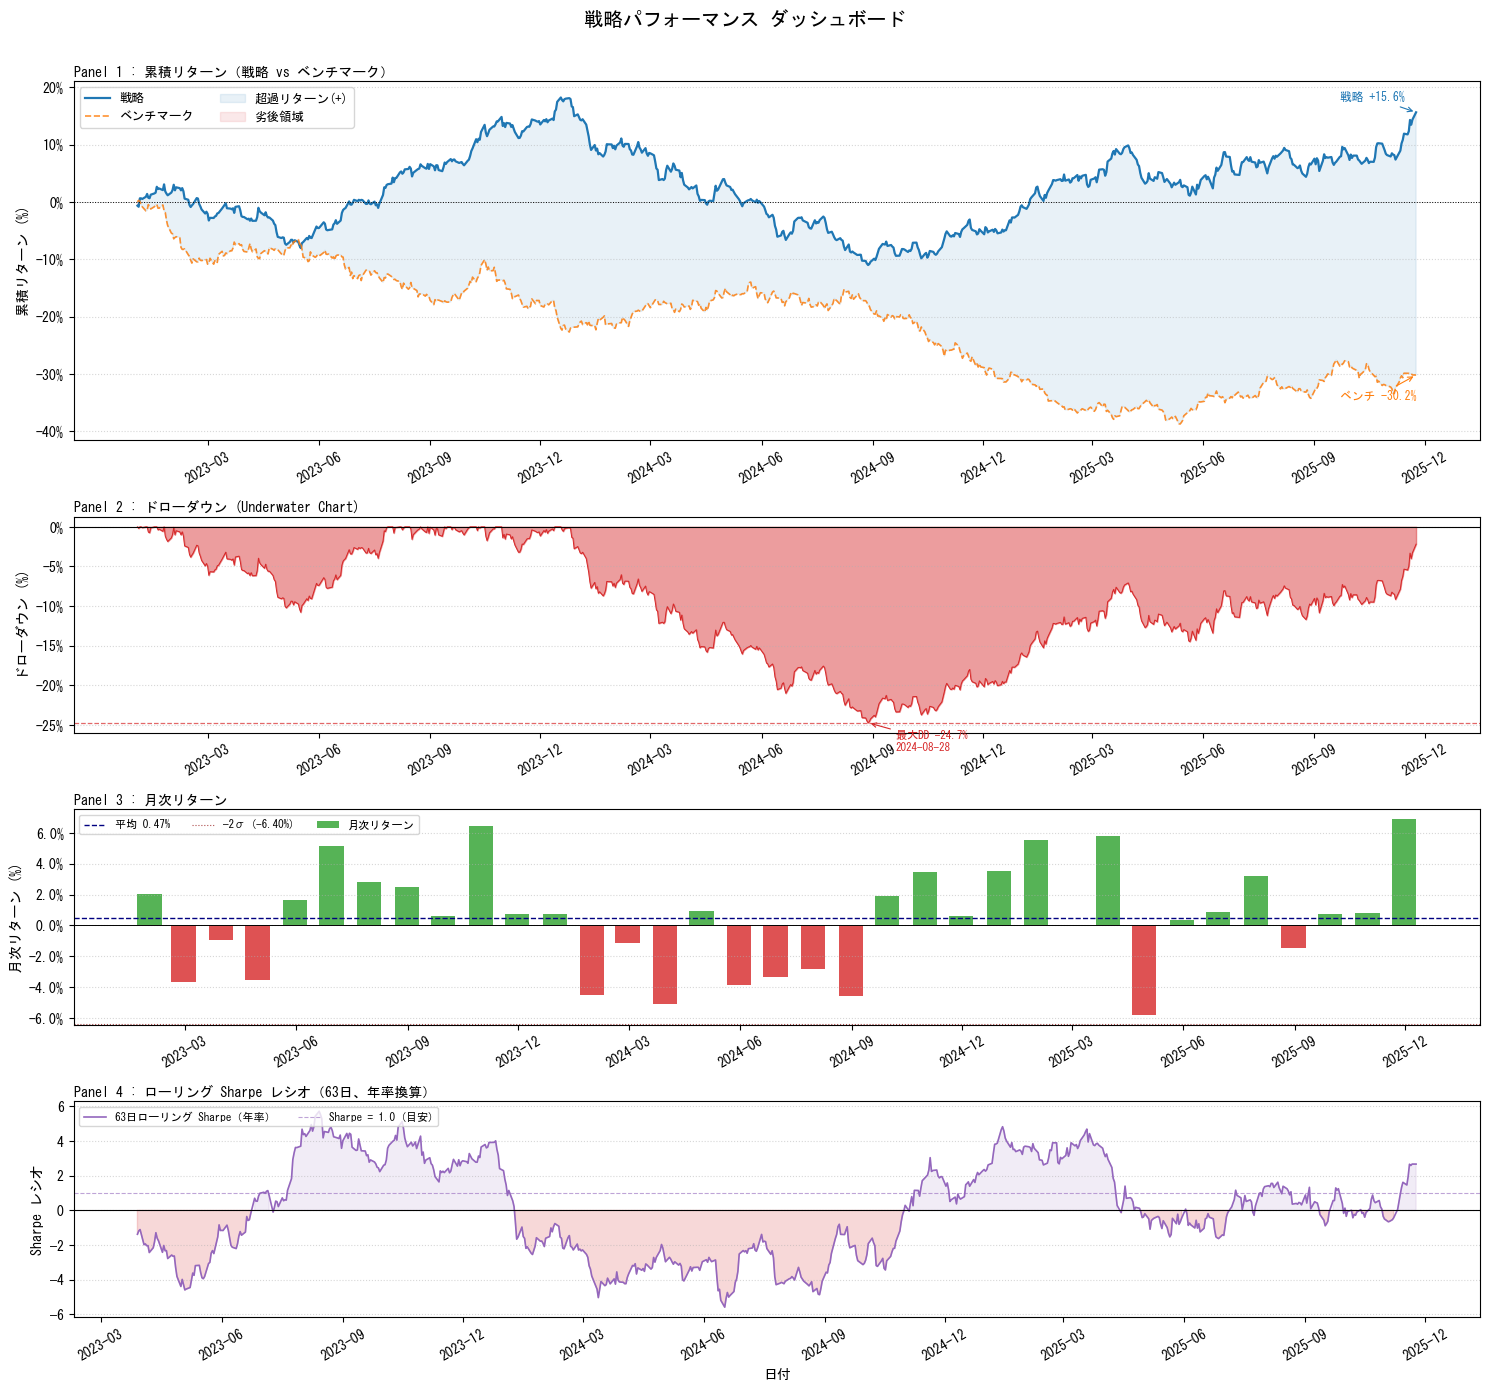

✓ perf_A_dashboard.png を保存しました


In [14]:
# ════════════════════════════════════════════════════════════════════
# 図A: 4段パネル パフォーマンスダッシュボード
#   Panel 1 — 累積リターン（戦略 vs ベンチマーク）
#   Panel 2 — ドローダウン（Underwater chart）
#   Panel 3 — 月次リターン（棒グラフ）
#   Panel 4 — ローリング Sharpe レシオ（63日）
# ════════════════════════════════════════════════════════════════════

DATE_FMT  = mdates.DateFormatter("%Y-%m")
DATE_LOC  = mdates.MonthLocator(interval=3)

C_STRAT  = "#1f77b4"   # 戦略: blue
C_BENCH  = "#ff7f0e"   # ベンチ: orange
C_DD     = "#d62728"   # ドローダウン: red
C_POS    = "#2ca02c"   # 正月次: green
C_NEG    = "#d62728"   # 負月次: red
C_SHARPE = "#9467bd"   # Sharpe: purple

fig, axes = plt.subplots(
    4, 1, figsize=(15, 14), sharex=False,
    gridspec_kw={"height_ratios": [2.5, 1.5, 1.5, 1.5]},
)
fig.suptitle("戦略パフォーマンス ダッシュボード", fontsize=14, fontweight="bold", y=0.99)

dates = pf["date"]

# ── Panel 1: 累積リターン ────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(dates, (pf["cum_strat"] - 1) * 100, color=C_STRAT, linewidth=1.6,
         label="戦略")
ax1.plot(dates, (pf["cum_bench"] - 1) * 100, color=C_BENCH, linewidth=1.2,
         linestyle="--", alpha=0.85, label="ベンチマーク")
ax1.fill_between(dates,
                 (pf["cum_strat"] - 1) * 100,
                 (pf["cum_bench"] - 1) * 100,
                 where=((pf["cum_strat"] - 1) >= (pf["cum_bench"] - 1)),
                 color=C_STRAT, alpha=0.10, label="超過リターン(+)")
ax1.fill_between(dates,
                 (pf["cum_strat"] - 1) * 100,
                 (pf["cum_bench"] - 1) * 100,
                 where=((pf["cum_strat"] - 1) < (pf["cum_bench"] - 1)),
                 color=C_DD, alpha=0.10, label="劣後領域")

# 最終値注釈
ax1.annotate(
    f"戦略 {(pf['cum_strat'].iloc[-1]-1)*100:+.1f}%",
    xy=(dates.iloc[-1], (pf["cum_strat"].iloc[-1] - 1) * 100),
    xytext=(-55, 8), textcoords="offset points",
    fontsize=8.5, color=C_STRAT,
    arrowprops=dict(arrowstyle="->", color=C_STRAT, lw=0.8),
)
ax1.annotate(
    f"ベンチ {(pf['cum_bench'].iloc[-1]-1)*100:+.1f}%",
    xy=(dates.iloc[-1], (pf["cum_bench"].iloc[-1] - 1) * 100),
    xytext=(-55, -18), textcoords="offset points",
    fontsize=8.5, color=C_BENCH,
    arrowprops=dict(arrowstyle="->", color=C_BENCH, lw=0.8),
)
ax1.set_ylabel("累積リターン (%)", fontsize=10)
ax1.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.legend(loc="upper left", fontsize=9, ncol=2)
ax1.grid(axis="y", linestyle=":", alpha=0.5)
ax1.set_title("Panel 1 : 累積リターン（戦略 vs ベンチマーク）", fontsize=10, loc="left", pad=3)
ax1.xaxis.set_major_formatter(DATE_FMT)
ax1.xaxis.set_major_locator(DATE_LOC)
ax1.tick_params(axis="x", labelrotation=30)

# ── Panel 2: ドローダウン（Underwater）──────────────────────────────
ax2 = axes[1]
ax2.fill_between(dates, pf["drawdown"] * 100, 0, color=C_DD, alpha=0.45,
                 label="ドローダウン")
ax2.plot(dates, pf["drawdown"] * 100, color=C_DD, linewidth=0.7)

max_dd_idx = pf["drawdown"].idxmin()
max_dd_val = pf["drawdown"].iloc[max_dd_idx]
max_dd_date = dates.iloc[max_dd_idx]
ax2.axhline(max_dd_val * 100, color=C_DD, linewidth=0.9, linestyle="--", alpha=0.7)
ax2.annotate(
    f"最大DD {max_dd_val*100:.1f}%\n{max_dd_date.strftime('%Y-%m-%d')}",
    xy=(max_dd_date, max_dd_val * 100),
    xytext=(20, -20), textcoords="offset points",
    fontsize=8, color=C_DD,
    arrowprops=dict(arrowstyle="->", color=C_DD, lw=0.8),
)
ax2.set_ylabel("ドローダウン (%)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.axhline(0, color="black", linewidth=0.8)
ax2.grid(axis="y", linestyle=":", alpha=0.5)
ax2.set_title("Panel 2 : ドローダウン (Underwater Chart)", fontsize=10, loc="left", pad=3)
ax2.xaxis.set_major_formatter(DATE_FMT)
ax2.xaxis.set_major_locator(DATE_LOC)
ax2.tick_params(axis="x", labelrotation=30)

# ── Panel 3: 月次リターン棒グラフ ────────────────────────────────────
ax3 = axes[2]
mo_dates = pf_monthly["date"]
mo_rets  = pf_monthly["monthly_return"] * 100
bar_colors = [C_POS if v >= 0 else C_NEG for v in mo_rets]
ax3.bar(mo_dates, mo_rets, color=bar_colors, alpha=0.80,
        width=20, label="月次リターン")

# ±2σ 水平線
mo_mean = mo_rets.mean()
mo_std  = mo_rets.std()
ax3.axhline(mo_mean, color="navy", linewidth=1.0, linestyle="--",
            label=f"平均 {mo_mean:.2f}%")
ax3.axhline(mo_mean - 2 * mo_std, color="darkred", linewidth=0.8,
            linestyle=":", alpha=0.7, label=f"−2σ ({mo_mean - 2*mo_std:.2f}%)")
ax3.axhline(0, color="black", linewidth=0.7)
ax3.set_ylabel("月次リターン (%)", fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax3.legend(loc="upper left", fontsize=8, ncol=3)
ax3.grid(axis="y", linestyle=":", alpha=0.5)
ax3.set_title("Panel 3 : 月次リターン", fontsize=10, loc="left", pad=3)
ax3.xaxis.set_major_formatter(DATE_FMT)
ax3.xaxis.set_major_locator(DATE_LOC)
ax3.tick_params(axis="x", labelrotation=30)

# ── Panel 4: ローリング Sharpe ───────────────────────────────────────
ax4 = axes[3]
roll_sh = pf["roll_sharpe"].dropna()
roll_sh_dates = dates[pf["roll_sharpe"].notna()]

ax4.plot(roll_sh_dates, roll_sh, color=C_SHARPE, linewidth=1.2,
         label="63日ローリング Sharpe（年率）")
ax4.fill_between(roll_sh_dates, roll_sh, 0,
                 where=(roll_sh >= 0), color=C_SHARPE, alpha=0.12)
ax4.fill_between(roll_sh_dates, roll_sh, 0,
                 where=(roll_sh < 0), color=C_DD, alpha=0.18)
ax4.axhline(0, color="black", linewidth=0.8)
ax4.axhline(1.0, color=C_SHARPE, linewidth=0.8, linestyle="--", alpha=0.6,
            label="Sharpe = 1.0 (目安)")
ax4.set_ylabel("Sharpe レシオ", fontsize=10)
ax4.legend(loc="upper left", fontsize=8, ncol=2)
ax4.grid(axis="y", linestyle=":", alpha=0.5)
ax4.set_title("Panel 4 : ローリング Sharpe レシオ（63日、年率換算）", fontsize=10, loc="left", pad=3)
ax4.xaxis.set_major_formatter(DATE_FMT)
ax4.xaxis.set_major_locator(DATE_LOC)
ax4.set_xlabel("日付", fontsize=10)
ax4.tick_params(axis="x", labelrotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig("perf_A_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ perf_A_dashboard.png を保存しました")


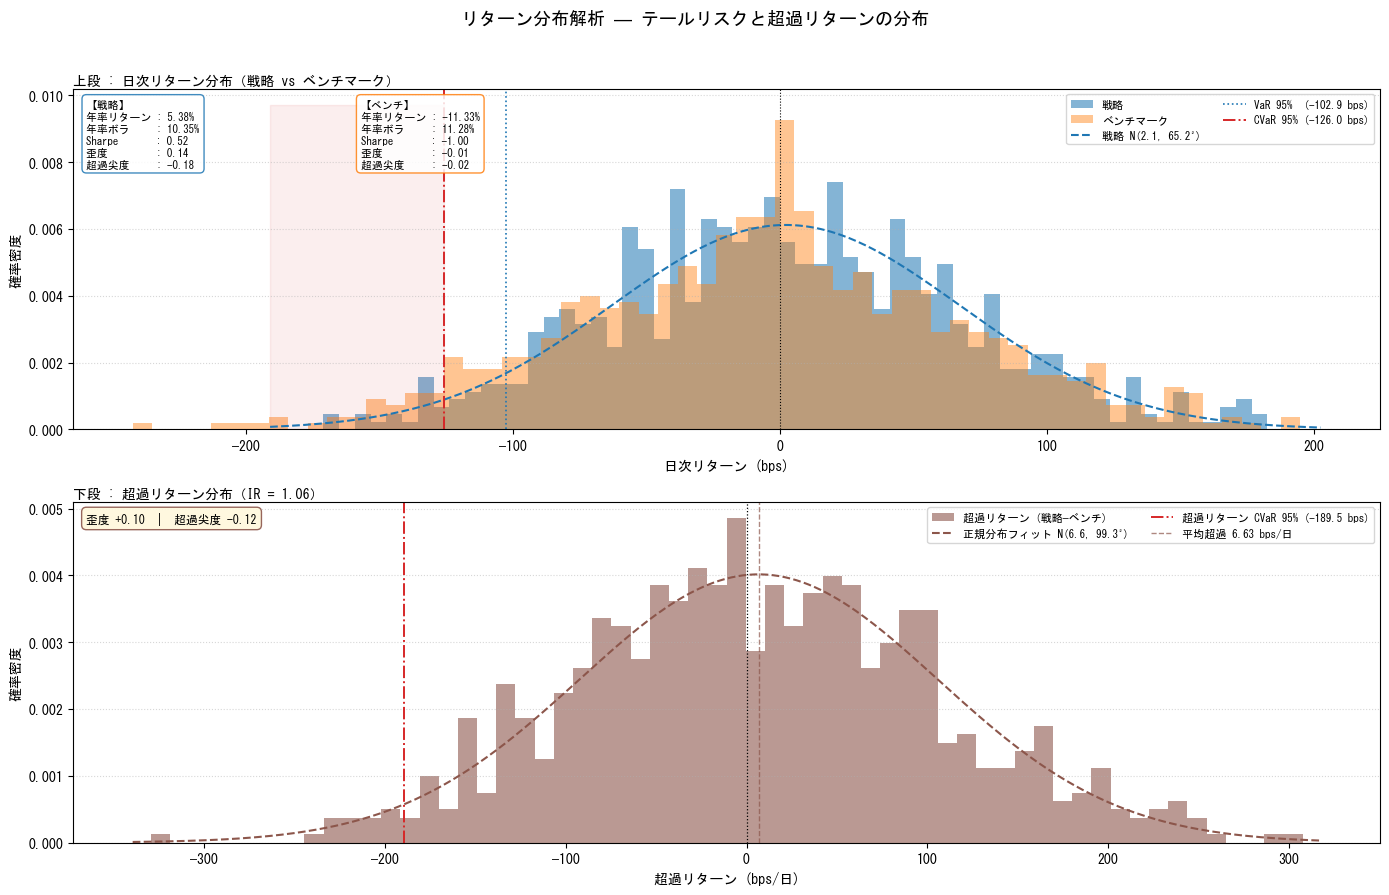

✓ perf_B_distribution.png を保存しました


In [15]:
# ════════════════════════════════════════════════════════════════════
# 図B: リターン分布解析（2段）
#   上段 — 日次リターンのヒストグラム（戦略 vs ベンチマーク）
#          VaR(95%) / CVaR(95%) を注釈
#   下段 — 超過リターン（戦略 − ベンチマーク）の分布 + 正規分布比較
# ════════════════════════════════════════════════════════════════════

from scipy.stats import norm as sp_norm

# ── 統計量を計算 ──────────────────────────────────────────────────────
sr  = pf["strategy_return"].dropna().values
br  = pf["benchmark_return"].dropna().values
er  = (sr - br)  # 日次超過リターン

def _var_cvar(r, level=0.05):
    """VaR と CVaR（左テール、levelは有意水準）を返す"""
    sorted_r = np.sort(r)
    idx_var  = int(np.floor(level * len(sorted_r)))
    var  = sorted_r[idx_var]
    cvar = sorted_r[:idx_var].mean()
    return var, cvar

var_s,  cvar_s  = _var_cvar(sr)
var_b,  cvar_b  = _var_cvar(br)
var_er, cvar_er = _var_cvar(er)

# スケーリング（bps で表示する）
to_bps = 100 * 100   # → bps
sr_bps = sr  * 10_000
br_bps = br  * 10_000
er_bps = er  * 10_000

# ── サマリー統計テキスト ──────────────────────────────────────────────
def _stats_text(label, r):
    ann = np.mean(r) * 252
    vol = np.std(r) * np.sqrt(252)
    sr_  = ann / vol if vol > 0 else np.nan
    skew = pd.Series(r).skew()
    kurt = pd.Series(r).kurtosis()  # excess kurtosis
    return (f"{label}\n"
            f"年率リターン : {ann*100:.2f}%\n"
            f"年率ボラ     : {vol*100:.2f}%\n"
            f"Sharpe       : {sr_:.2f}\n"
            f"歪度         : {skew:.2f}\n"
            f"超過尖度     : {kurt:.2f}")

# ── プロット ─────────────────────────────────────────────────────────
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("リターン分布解析 ― テールリスクと超過リターンの分布",
             fontsize=13, fontweight="bold", y=0.99)

# ── 上段: 戦略 vs ベンチマーク ヒストグラム ──────────────────────────
BINS = 60

ax_top.hist(sr_bps, bins=BINS, color=C_STRAT, alpha=0.55,
            density=True, label="戦略")
ax_top.hist(br_bps, bins=BINS, color=C_BENCH, alpha=0.45,
            density=True, label="ベンチマーク")

# 正規分布フィット（戦略）
xs = np.linspace(sr_bps.min() - 20, sr_bps.max() + 20, 400)
mu_s, sd_s = sr_bps.mean(), sr_bps.std()
ax_top.plot(xs, sp_norm.pdf(xs, mu_s, sd_s), color=C_STRAT,
            linewidth=1.5, linestyle="--", label=f"戦略 N({mu_s:.1f}, {sd_s:.1f}²)")

# VaR / CVaR 注釈（戦略）
var_x  = var_s  * 10_000
cvar_x = cvar_s * 10_000
ax_top.axvline(var_x,  color=C_STRAT, linewidth=1.2, linestyle=":",
               label=f"VaR 95%  ({var_x:.1f} bps)")
ax_top.axvline(cvar_x, color=C_DD,    linewidth=1.4, linestyle="-.",
               label=f"CVaR 95% ({cvar_x:.1f} bps)")
ax_top.fill_betweenx(
    [0, ax_top.get_ylim()[1] if ax_top.get_ylim()[1] > 0 else 0.05],
    xs.min(), cvar_x, color=C_DD, alpha=0.08,
)

ax_top.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax_top.set_xlabel("日次リターン (bps)", fontsize=10)
ax_top.set_ylabel("確率密度", fontsize=10)
ax_top.set_title("上段 : 日次リターン分布（戦略 vs ベンチマーク）", fontsize=10, loc="left", pad=3)
ax_top.legend(loc="upper right", fontsize=8, ncol=2)
ax_top.grid(axis="y", linestyle=":", alpha=0.5)

# 統計サマリーを枠内テキストで表示
ax_top.text(0.01, 0.97, _stats_text("【戦略】", sr),
            transform=ax_top.transAxes, fontsize=7.8,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C_STRAT, alpha=0.85))
ax_top.text(0.22, 0.97, _stats_text("【ベンチ】", br),
            transform=ax_top.transAxes, fontsize=7.8,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C_BENCH, alpha=0.85))

# ── 下段: 超過リターン分布（戦略 − ベンチマーク）─────────────────────
ax_bot.hist(er_bps, bins=BINS, color="#8c564b", alpha=0.60,
            density=True, label="超過リターン (戦略−ベンチ)")

xs_e = np.linspace(er_bps.min() - 10, er_bps.max() + 10, 400)
mu_e, sd_e = er_bps.mean(), er_bps.std()
ax_bot.plot(xs_e, sp_norm.pdf(xs_e, mu_e, sd_e), color="#8c564b",
            linewidth=1.5, linestyle="--",
            label=f"正規分布フィット N({mu_e:.1f}, {sd_e:.1f}²)")

# CVaR（超過リターン）
cvar_ex = cvar_er * 10_000
ax_bot.axvline(cvar_ex, color=C_DD, linewidth=1.4, linestyle="-.",
               label=f"超過リターン CVaR 95% ({cvar_ex:.1f} bps)")

ax_bot.axvline(0, color="black", linewidth=0.9, linestyle=":")
ax_bot.axvline(mu_e, color="#8c564b", linewidth=1.0, linestyle="--",
               alpha=0.7, label=f"平均超過 {mu_e:.2f} bps/日")

# Information Ratio
ir = mu_e / sd_e * np.sqrt(252) if sd_e > 0 else np.nan
ax_bot.set_xlabel("超過リターン (bps/日)", fontsize=10)
ax_bot.set_ylabel("確率密度", fontsize=10)
ax_bot.set_title(
    f"下段 : 超過リターン分布（IR = {ir:.2f}）",
    fontsize=10, loc="left", pad=3,
)
ax_bot.legend(loc="upper right", fontsize=8, ncol=2)
ax_bot.grid(axis="y", linestyle=":", alpha=0.5)

# 正規分布との乖離（尖度テキスト）
skew_e = pd.Series(er).skew()
kurt_e = pd.Series(er).kurtosis()
note = f"歪度 {skew_e:+.2f}  |  超過尖度 {kurt_e:+.2f}"
if kurt_e > 1.5:
    note += "\n→ 正規分布より裾が厚い（fat tail）"
ax_bot.text(0.01, 0.97, note, transform=ax_bot.transAxes,
            fontsize=8.5, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="#fff8dc", ec="#8c564b", alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("perf_B_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ perf_B_distribution.png を保存しました")


## 各図が示すもの・補足するリスク

### 図A（4段パネルダッシュボード）

| パネル | 示すもの | 補足するリスク・弱点 |
|---|---|---|
| **累積リターン** | ベンチマークに対する絶対的な成績の推移 | 「いつ負けたか」の文脈が分かる。累積グラフだけでは長期低迷が薄まって見える |
| **ドローダウン** | ピークからの下落幅（資本毀損リスク） | 最大DD・回復期間は、投資家の「解約判断」を左右する最重要指標。累積グラフには出てこない |
| **月次リターン** | 月単位のバラツキ・連続マイナス月の有無 | 年次では良くても特定月に集中した損失がないか。季節性やイベントへの感応度も見える |
| **ローリング Sharpe** | リスク調整後パフォーマンスの経時安定性 | Sharpe が正から負に転じた局面はレジーム変化のサイン。戦略の「持続性」の検証になる |

### 図B（リターン分布解析）

| パネル | 示すもの | 補足するリスク・弱点 |
|---|---|---|
| **上段（日次分布）** | リターンの形状・テールの重さ・正規分布からの乖離 | 超過尖度（fat tail）は、モデルベースVaRが過小評価するリスクを示す。累積グラフでは見えない |
| **VaR / CVaR** | 最悪5%の日が平均的にどれだけ悪いか | VaRは「閾値」、CVaRは「超えたときの平均損失」。リスク予算設定やストレステストに直結 |
| **下段（超過リターン）** | 戦略がベンチマークを継続的に上回る能力（IR） | IRが低いと「ベンチに勝っているのは運次第」。歪度がマイナスは「負けるときに大きく負ける」構造を示す |

> **一言まとめ：** 図Aは「いつ・どれだけ・どのように戦略が機能したか」の時系列診断であり、図Bは「確率的に見てこの戦略はどの程度信頼できるか」のリスク定量化である。2図セットで初めて、投資家・PMが必要な説明責任（accountability）を果たせる。